# Size scaling -- loading and filtering

How does the time to **load** and **filter** a zarr-vectors store
compare against the canonical file format for each geometry type as
the dataset grows?  Three panels, one per geometry, log-log axes.

| Panel | Geometry | zarr-vectors | Competitor |
| --- | --- | --- | --- |
| A | point cloud | `read_points` | PLY (`plyfile`) |
| B | graph | `read_graph` | edge-list + node CSV (`pandas`) |
| C | mesh | `read_mesh` | OBJ (pure-Python parser) |

For each `N` we measure two operations:

- **load_full** -- read every vertex / edge / face into memory.
- **load_bbox** -- read only the 1 % volume bounding box at the
  centre of the cube.  zarr-vectors uses the public `bbox=` argument
  to the read function; competitors read the whole file and then
  filter in numpy (no competitor supports a native spatial sub-read).

Each timing is averaged over **`N_RUNS = 10` runs**; plots show the
mean with shaded **95 % CI** band (Student's t, df=9).  Writes happen
once per `N` outside the timing loop -- only reads are benchmarked.

Requires `matplotlib`, `plyfile`, and `pandas` in addition to the
usual deps.  Runtime: ~5 minutes on a laptop (the 100 K mesh case
dominates because the pure-Python OBJ parser is the long pole).

In [1]:
import os, time, tempfile, shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _time(fn, *args, **kwargs):
    """Call fn(*args, **kwargs); return (elapsed_seconds, result)."""
    t0 = time.perf_counter()
    out = fn(*args, **kwargs)
    return time.perf_counter() - t0, out


def _store_bytes(path):
    """Total on-disk size of a store directory, in bytes."""
    p = Path(path)
    if not p.exists():
        return 0
    if p.is_file():
        return p.stat().st_size
    return sum(f.stat().st_size for f in p.rglob('*') if f.is_file())


def _new_store(prefix):
    """Fresh tempdir + zarrvectors path."""
    return Path(tempfile.mkdtemp(prefix=f'zvbench_{prefix}_')) / 'store.zarrvectors'


def _new_file(prefix, suffix):
    """Fresh tempdir + competitor-format file path."""
    return Path(tempfile.mkdtemp(prefix=f'compbench_{prefix}_')) / f'data.{suffix}'


N_RUNS = 10
T95_DF9 = 2.262  # scipy.stats.t.ppf(0.975, df=9) -- hard-coded to avoid scipy dep


def _mean_ci95(samples):
    """(mean, half-width) for a 1-D sample using Student's t, df=n-1."""
    arr = np.asarray(samples, dtype=float)
    if arr.size < 2:
        return float(arr.mean()) if arr.size else 0.0, 0.0
    m = arr.mean()
    s = arr.std(ddof=1)
    hw = T95_DF9 * s / np.sqrt(arr.size)
    return float(m), float(hw)


def _repeat(fn, *args, n_runs=None, **kwargs):
    """Run fn n_runs times; return (mean_s, ci_hw_s)."""
    n = n_runs if n_runs is not None else N_RUNS
    samples = []
    for _ in range(n):
        t, _ = _time(fn, *args, **kwargs)
        samples.append(t)
    return _mean_ci95(samples)

## 1 · Setup

In [2]:
from zarr_vectors.types.points import write_points, read_points
from zarr_vectors.types.graphs import write_graph, read_graph
from zarr_vectors.types.meshes import write_mesh, read_mesh

SIZES = [1_000, 10_000, 100_000]   # vertex count per panel
CHUNK = (200.0, 200.0, 200.0)
BIN   = (50.0, 50.0, 50.0)
SEED  = 0
EXTENT = 1000.0                     # cube side; bbox covers ~1% of volume.
BBOX_HW = EXTENT * (0.01 ** (1/3)) / 2  # half-width of the 1% bbox
BBOX_CENTRE = np.array([EXTENT / 2] * 3)
BBOX_LOW    = BBOX_CENTRE - BBOX_HW
BBOX_HIGH   = BBOX_CENTRE + BBOX_HW
print(f'bbox half-width: {BBOX_HW:.2f}  (~1% volume of [0,{EXTENT}]^3)')

bbox half-width: 107.72  (~1% volume of [0,1000.0]^3)


In [3]:
# ----- PLY (point cloud) -----------------------------------------------------
def ply_write_points(path, positions):
    from plyfile import PlyData, PlyElement
    n = len(positions)
    arr = np.zeros(n, dtype=[('x', 'f4'), ('y', 'f4'), ('z', 'f4')])
    arr['x'] = positions[:, 0]
    arr['y'] = positions[:, 1]
    arr['z'] = positions[:, 2]
    el = PlyElement.describe(arr, 'vertex')
    PlyData([el], text=False).write(str(path))


def ply_load_full(path):
    from plyfile import PlyData
    ply = PlyData.read(str(path))
    v = ply['vertex']
    return np.stack([v['x'], v['y'], v['z']], axis=1)


def ply_load_bbox(path, low, high):
    pts = ply_load_full(path)
    mask = np.all((pts >= np.asarray(low)) & (pts <= np.asarray(high)), axis=1)
    return pts[mask]


# ----- CSV edge-list (graph) -------------------------------------------------
def csv_write_graph(edges_path, nodes_path, positions, edges):
    pd.DataFrame({
        'node_id': np.arange(len(positions)),
        'x': positions[:, 0],
        'y': positions[:, 1],
        'z': positions[:, 2],
    }).to_csv(nodes_path, index=False)
    pd.DataFrame({
        'source': edges[:, 0],
        'target': edges[:, 1],
    }).to_csv(edges_path, index=False)


def csv_load_graph(edges_path, nodes_path):
    nodes = pd.read_csv(nodes_path)
    edges_df = pd.read_csv(edges_path)
    pos = nodes[['x', 'y', 'z']].to_numpy()
    e = edges_df[['source', 'target']].to_numpy()
    return pos, e


def csv_load_graph_bbox(edges_path, nodes_path, low, high):
    pos, e = csv_load_graph(edges_path, nodes_path)
    mask = np.all((pos >= np.asarray(low)) & (pos <= np.asarray(high)), axis=1)
    keep = np.where(mask)[0]
    keep_set = set(int(k) for k in keep)
    edge_mask = np.array([int(s) in keep_set and int(t) in keep_set for s, t in e])
    return pos[mask], e[edge_mask]


# ----- OBJ (mesh) -- pure-Python parser for fair comparison ------------------
def obj_write_mesh(path, vertices, faces):
    with open(path, 'w') as f:
        for v in vertices:
            f.write(f'v {v[0]:.6f} {v[1]:.6f} {v[2]:.6f}\n')
        for tri in faces:
            f.write(f'f {tri[0]+1} {tri[1]+1} {tri[2]+1}\n')


def obj_load_full(path):
    verts = []
    faces = []
    with open(path) as f:
        for line in f:
            if line.startswith('v '):
                parts = line.split()
                verts.append((float(parts[1]), float(parts[2]), float(parts[3])))
            elif line.startswith('f '):
                parts = line.split()
                tri = tuple(int(p.split('/')[0]) - 1 for p in parts[1:4])
                faces.append(tri)
    return np.asarray(verts, dtype=np.float32), np.asarray(faces, dtype=np.int64)


def obj_load_bbox(path, low, high):
    v, f = obj_load_full(path)
    mask = np.all((v >= np.asarray(low)) & (v <= np.asarray(high)), axis=1)
    keep = np.where(mask)[0]
    keep_set = set(int(k) for k in keep)
    face_mask = np.array([
        int(a) in keep_set and int(b) in keep_set and int(c) in keep_set
        for a, b, c in f
    ])
    return v[mask], f[face_mask]

## 2 · Build inputs (one zarr-vectors + one competitor per N, per geometry)

In [4]:
rng = np.random.default_rng(SEED)


def _gen_points(n):
    return rng.uniform(0, EXTENT, (n, 3)).astype(np.float32)


def _gen_graph(n):
    pos = rng.uniform(0, EXTENT, (n, 3)).astype(np.float32)
    src = rng.integers(0, n, size=3 * n // 2)
    dst = rng.integers(0, n, size=3 * n // 2)
    edges = np.stack([src[src != dst], dst[src != dst]], axis=1).astype(np.int64)
    return pos, edges


def _gen_mesh(n):
    side = max(int(np.sqrt(n)), 2)
    xs, ys = np.meshgrid(np.linspace(0, EXTENT, side), np.linspace(0, EXTENT, side))
    zs = rng.uniform(0, EXTENT * 0.1, (side, side))
    v = np.stack([xs, ys, zs], axis=-1).reshape(-1, 3).astype(np.float32)
    i = np.arange(side - 1); j = np.arange(side - 1)
    ii, jj = np.meshgrid(i, j, indexing='ij')
    a = (ii * side + jj).ravel(); b = a + 1; c = a + side; d = c + 1
    f = np.concatenate([
        np.stack([a, b, c], axis=1),
        np.stack([b, d, c], axis=1),
    ]).astype(np.int64)
    return v, f


# inputs[panel][n] = dict with 'zv' (store path) and 'comp' (file path[s])
inputs = {'points': {}, 'graph': {}, 'mesh': {}}

for n in SIZES:
    # Points
    pts = _gen_points(n)
    zv = _new_store(f'points_{n}')
    write_points(zv, pts, chunk_shape=CHUNK, bin_shape=BIN)
    comp = _new_file(f'points_{n}', 'ply')
    ply_write_points(comp, pts)
    inputs['points'][n] = {'zv': zv, 'comp': comp}

    # Graph
    pos, edges = _gen_graph(n)
    zv = _new_store(f'graph_{n}')
    write_graph(zv, pos, edges, chunk_shape=CHUNK, bin_shape=BIN)
    edges_csv = _new_file(f'graph_edges_{n}', 'csv')
    nodes_csv = edges_csv.parent / 'nodes.csv'
    csv_write_graph(edges_csv, nodes_csv, pos, edges)
    inputs['graph'][n] = {'zv': zv, 'comp': (edges_csv, nodes_csv)}

    # Mesh
    v, f = _gen_mesh(n)
    zv = _new_store(f'mesh_{n}')
    write_mesh(zv, v, f, chunk_shape=CHUNK, bin_shape=BIN)
    comp = _new_file(f'mesh_{n}', 'obj')
    obj_write_mesh(comp, v, f)
    inputs['mesh'][n] = {'zv': zv, 'comp': comp}

print('built', sum(len(v) for v in inputs.values()), 'input stores')

built 9 input stores


## 3 · Run the sweep (reads only)

In [5]:
PANELS = ['points', 'graph', 'mesh']
OPS    = ['load_full', 'load_bbox']

# raw[panel][op][prefix] = array shape (len(SIZES), N_RUNS)
raw = {
    p: {op: {prefix: np.zeros((len(SIZES), N_RUNS)) for prefix in ('zv', 'comp')}
        for op in OPS}
    for p in PANELS
}


def _bench(panel, op, prefix, n):
    inp = inputs[panel][n]
    if panel == 'points':
        if prefix == 'zv':
            if op == 'load_full':
                return _time(read_points, inp['zv'])
            return _time(read_points, inp['zv'],
                         bbox=(BBOX_LOW.tolist(), BBOX_HIGH.tolist()))
        # competitor: PLY
        if op == 'load_full':
            return _time(ply_load_full, inp['comp'])
        return _time(ply_load_bbox, inp['comp'], BBOX_LOW, BBOX_HIGH)

    if panel == 'graph':
        if prefix == 'zv':
            if op == 'load_full':
                return _time(read_graph, inp['zv'])
            return _time(read_graph, inp['zv'],
                         bbox=(BBOX_LOW.tolist(), BBOX_HIGH.tolist()))
        edges_csv, nodes_csv = inp['comp']
        if op == 'load_full':
            return _time(csv_load_graph, edges_csv, nodes_csv)
        return _time(csv_load_graph_bbox, edges_csv, nodes_csv,
                     BBOX_LOW, BBOX_HIGH)

    # mesh
    if prefix == 'zv':
        if op == 'load_full':
            return _time(read_mesh, inp['zv'])
        return _time(read_mesh, inp['zv'],
                     bbox=(BBOX_LOW.tolist(), BBOX_HIGH.tolist()))
    if op == 'load_full':
        return _time(obj_load_full, inp['comp'])
    return _time(obj_load_bbox, inp['comp'], BBOX_LOW, BBOX_HIGH)


for panel in PANELS:
    for i, n in enumerate(SIZES):
        for op in OPS:
            for prefix in ('zv', 'comp'):
                for run in range(N_RUNS):
                    t, _ = _bench(panel, op, prefix, n)
                    raw[panel][op][prefix][i, run] = t

# Tidy long-form df.
rows = []
for panel in PANELS:
    for i, n in enumerate(SIZES):
        for op in OPS:
            for prefix in ('zv', 'comp'):
                mean, hw = _mean_ci95(raw[panel][op][prefix][i])
                rows.append({
                    'panel':  panel,
                    'N':      n,
                    'op':     op,
                    'format': prefix,
                    'mean_s': round(mean, 4),
                    'ci_hw':  round(hw, 4),
                })
df = pd.DataFrame(rows)

## 4 · Results

In [6]:
df

,panel,N,op,format,mean_s,ci_hw
0,points,1000,load_full,zv,0.3753,0.0631
1,points,1000,load_full,comp,0.0015,0.0028
2,points,1000,load_bbox,zv,0.3386,0.0209
3,points,1000,load_bbox,comp,0.0004,0.0001
4,points,10000,load_full,zv,0.3720,0.0671
5,points,10000,load_full,comp,0.0031,0.0058
6,points,10000,load_bbox,zv,0.3364,0.0214
7,points,10000,load_bbox,comp,0.0010,0.0003
8,points,100000,load_full,zv,0.3669,0.0628
9,points,100000,load_full,comp,0.0020,0.0024


## 5 · Plot

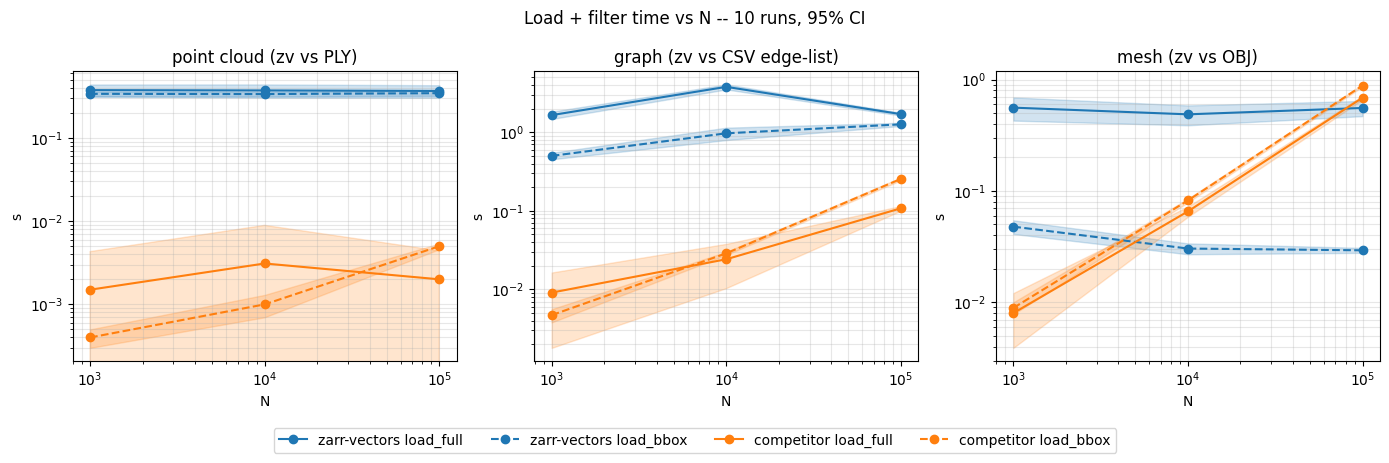

In [7]:
PANEL_TITLES = {
    'points': 'point cloud (zv vs PLY)',
    'graph':  'graph (zv vs CSV edge-list)',
    'mesh':   'mesh (zv vs OBJ)',
}
SERIES = [
    ('zarr-vectors load_full', 'zv',   'load_full', '#1f77b4', '-'),
    ('zarr-vectors load_bbox', 'zv',   'load_bbox', '#1f77b4', '--'),
    ('competitor load_full',   'comp', 'load_full', '#ff7f0e', '-'),
    ('competitor load_bbox',   'comp', 'load_bbox', '#ff7f0e', '--'),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
handles, labels = [], []

for ax, panel in zip(axes, PANELS):
    sub = df[df['panel'] == panel]
    for label, prefix, op, color, ls in SERIES:
        s = sub[(sub['format'] == prefix) & (sub['op'] == op)].sort_values('N')
        x    = s['N'].to_numpy()
        mean = s['mean_s'].to_numpy()
        hw   = s['ci_hw'].to_numpy()
        line, = ax.plot(x, mean, marker='o', color=color, linestyle=ls)
        ax.fill_between(x, mean - hw, mean + hw, color=color, alpha=0.20)
        if ax is axes[0]:
            handles.append(line)
            labels.append(label)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('N')
    ax.set_ylabel('s')
    ax.set_title(PANEL_TITLES[panel])
    ax.grid(True, which='both', alpha=0.3)

fig.suptitle(f'Load + filter time vs N -- {N_RUNS} runs, 95% CI')
fig.legend(handles, labels, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.02))
fig.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()